# HOMEWORK WEEK 1_1


# Bài 1

In [60]:
# Bài 1.1
import numpy as np

cau = ["machine learning is interesting", "deep learning is difficult", "machine learning requires math", "neural network is a machine learning algorithm",
       "I like going to the gym", "I go to the gym four times a week", "going to the gym is fun", "protein is necessary for training in the gym"]

vocab = sorted ({ w for s in cau for w in s.lower().split()})

def to_vector (s) :
    v = np.zeros(len(vocab))
    for w in s.lower().split() : 
       v [vocab.index(w)] += 1
    return v

X = np.array([to_vector(s) for s in cau])  #(so_cau , so_tu)
print("Shape of X:", X.shape)
print(X)

Shape of X: (8, 28)
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0.]
 [0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 1. 0. 0. 0. 0. 1. 0.
  0. 0. 0. 0.]
 [1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 1. 0. 0. 1. 1. 0. 0. 0.
  0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1.
  0. 1. 0. 0.]
 [1. 0. 0. 0. 0. 1. 0. 1. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.
  1. 1. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1. 0. 1. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.
  0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1.
  0. 0. 1. 0.]]


Ví dụ với bộ câu trên hàm sorted sẽ lọc ra được 28 từ riêng biệt sắp xếp theo alphabetical order :
vocab = 
- [
 'a', 'can', 'complex', 'deep', 'difficult', 'for', 'fun',
 'going', 'gym', 'i', 'in', 'interesting', 'is', 'learn',
 'learning', 'legs', 'like', 'machine', 'math', 'necessary',
 'networks', 'neural', 'patterns', 'protein', 'requires',
 'the', 'to', 'train', 'training', 'twice', 'week'
 ]

X.shape = (8,28) : có tổng cộng 8 câu và 28 từ phân biệt

Giải thích ma trận X:
- Mỗi hàng là một câu.
- Mỗi cột là một từ trong vocab.
- Giá trị X[i][j] là số lần từ j xuất hiện trong câu i.



In [61]:
# Bài 1.2

mean_vector = X.mean(axis=0)

print("X shape:", X.shape)
print("\nMean vector:", mean_vector)
print("Mean vector shape:", mean_vector.shape)

X_centered = X - mean_vector

print("Centered matrix shape:", X_centered.shape)

print(f"\nBroadcasting: {X.shape} - {mean_vector.shape} -> {X_centered.shape}")



X shape: (8, 28)

Mean vector: [0.25  0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.25  0.5   0.25  0.125
 0.125 0.625 0.5   0.125 0.375 0.125 0.125 0.125 0.125 0.125 0.125 0.5
 0.125 0.375 0.125 0.125]
Mean vector shape: (28,)
Centered matrix shape: (8, 28)

Broadcasting: (8, 28) - (28,) -> (8, 28)


Giải thích broadcasting: X có shape (8,28), mean_vector có shape (28,). 

Khi thực hiện phép trừ ma trận X - mean_vector, Numpy tự động broadcast mean_vector lại thành (8,31) bằng cách
lặp lại vector trung bình cho 8 hàng.

Vì vậy phép trừ vẫn thực hiện được và trả về kết quả có shape (8,28)


In [62]:
# Bài 1.3, 1.4

def cosine_similarity(X, Y=None):
    if(Y is None):
        Y = X
    
    Xn = X / np.linalg.norm(X, axis=1, keepdims=True)
    Yn = Y / np.linalg.norm(Y, axis=1, keepdims=True)

    return Xn @ Yn.T

sim = cosine_similarity(X)

def search(query, top_k=3):
    if(query not in cau):
        print("Query not in dataset")
        return
    
    q = to_vector(query)
    q = q.reshape(1,-1)

    similarity_scores = cosine_similarity(X,q).flatten()

    query_idx = cau.index(query)
    similarity_scores[query_idx] -= 1

    topk = np.argsort(similarity_scores)[::-1][:top_k]


    return [(cau[i], round(float(similarity_scores[i]),4)) for i in topk]

search("I like going to the gym", 5)



[('going to the gym is fun', 0.6667),
 ('I go to the gym four times a week', 0.5443),
 ('protein is necessary for training in the gym', 0.2887),
 ('I like going to the gym', 0.0),
 ('neural network is a machine learning algorithm', 0.0)]

Nhận xét :
- Cặp giống nhau nhất: "I like going to the gym" và "going to the gym is fun
- Cặp khác nhau nhất: Có một vài cặp có cosine similarity bằng 0, ví dụ như "deep learning is difficult" - "going to the gym is fun"

Kết quả trả về của cosine similarity matrix tương đối giống với trực giác về mặt ngữ nghĩa

# Bài 2

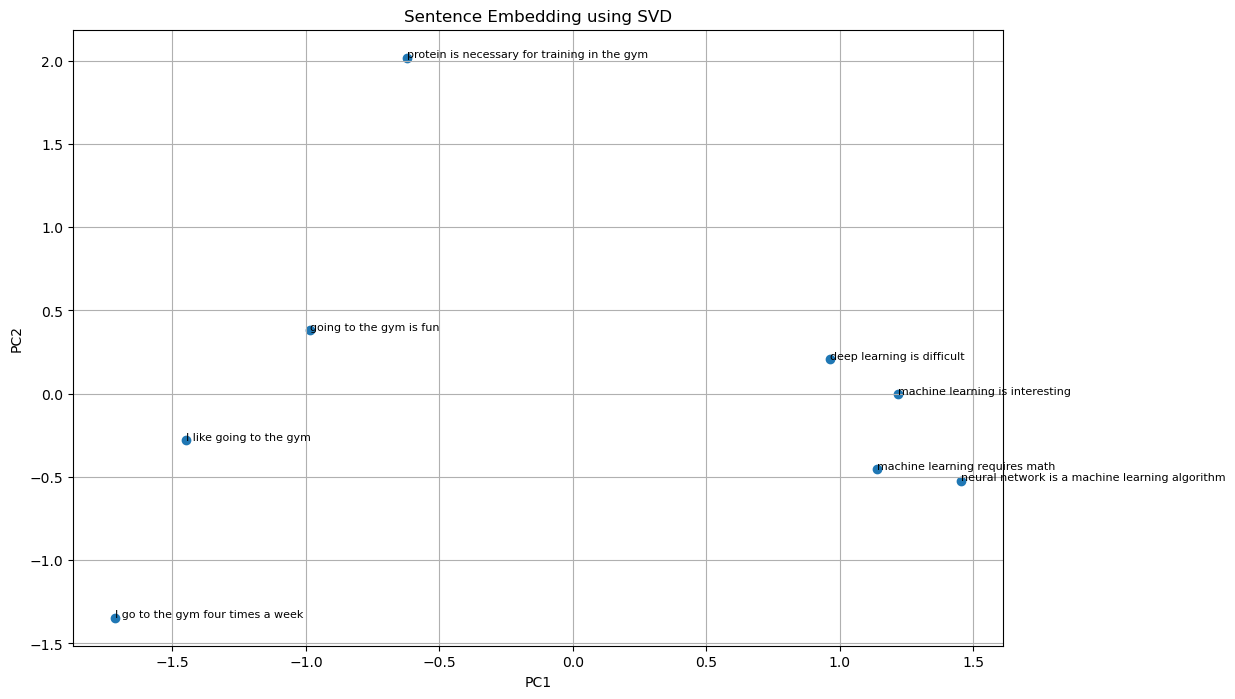

In [63]:
import matplotlib.pyplot as plt
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
coords = U [: , :2] * S [:2]

plt.figure(figsize=(12, 8))

plt.scatter(coords[:,0], coords[:,1])

for i, sentence in enumerate(cau):
    plt.annotate(
        sentence,
        (coords[i,0], coords[i,1]),
        fontsize=8
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Sentence Embedding using SVD")
plt.grid(True)

plt.show()